<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_1_SLR_SKLearn_vs_Statsmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: The Two Paradigms (Scikit-Learn vs. Statsmodels)

Author: Brad Sheese

---


## What This Notebook Is About

At the end of the preliminaries series we earned a pretty remarkable result. Given any two variables $x$ and $y$, the line that minimizes $\text{RSS}$ has slope and intercept that come straight from summary statistics we already know how to compute:

$$m = r \cdot \frac{\sigma_y}{\sigma_x}, \qquad b = \bar{y} - m\bar{x}$$

We even watched the green dashed line drop *exactly* onto the bottom of the RSS bowl. That formula **is** simple linear regression. There is nothing else.

So why do libraries like scikit-learn and statsmodels exist at all? Why not just compute $m$ and $b$ by hand forever?

Three reasons:

1. **They scale.** The hand formula is beautiful for one predictor. Once you have ten predictors, the closed-form solution involves matrix inverses and a lot of NumPy. The libraries handle that for you.
2. **They are the industry standard.** Every Python data scientist on Earth uses these two libraries. You need to be able to read their code.
3. **They split along an important philosophical line.** The same math ($\text{argmin}$ of $\text{RSS}$) gets packaged in two very different ways, for two very different audiences.

That third point is the point of this notebook. We'll meet both libraries, fit the *same* regression with each, and then, as a sanity check, verify that their answers agree with the hand formula from Notebook 17_0_5. No magic. Just two APIs wrapped around the same math.

> **The two paradigms:**
> - **scikit-learn**: built for *prediction*. Give it $X$, get $\hat{y}$. Fast, minimal, opinionated.
> - **statsmodels**: built for *inference*. Give it $X$ and $y$, get a statistics-textbook summary table with p-values, confidence intervals, and diagnostics.


## Setup

We'll use the **Palmer Penguins** dataset. It contains data about 344 penguins from three species on three islands in the Palmer Archipelago of Antarctica. It's the modern friendly replacement for the old Iris dataset.

Our $x$ will be `flipper_length_mm`, the length of the penguin's flipper in millimeters.

Our $y$ will be `body_mass_g`, the penguin's body mass in grams.

The scientific question is exactly what you'd expect: *do penguins with longer flippers tend to be heavier?* If so, by how much? That's a simple linear regression problem.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The two paradigms:
from sklearn.linear_model import LinearRegression    # prediction
import statsmodels.api as sm                         # inference

sns.set_style('whitegrid')

# Load Palmer Penguins (bundled with seaborn).
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)

print(f'Penguins (after dropping NaNs): {len(penguins)}')
penguins[['species', 'flipper_length_mm', 'body_mass_g']].head()

Penguins (after dropping NaNs): 333


,species,flipper_length_mm,body_mass_g
0,Adelie,181.0,3750.0
1,Adelie,186.0,3800.0
2,Adelie,195.0,3250.0
3,Adelie,193.0,3450.0
4,Adelie,190.0,3650.0


Rule from Notebook 17_0_2: always look at the data before modeling it.

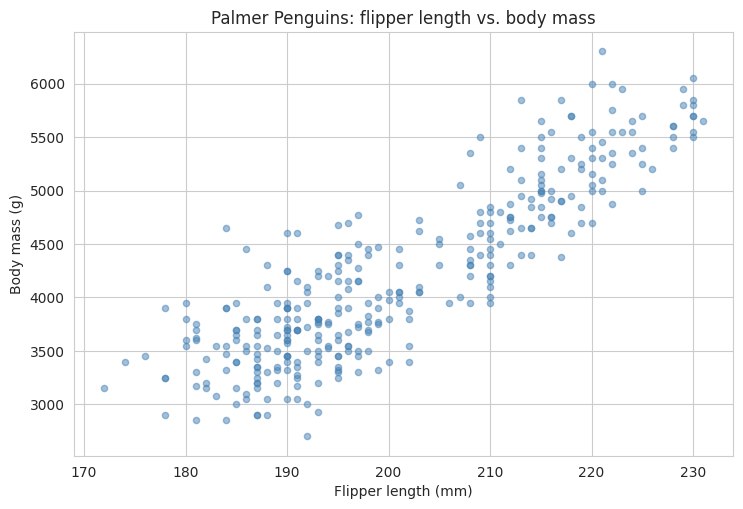

In [2]:
x = penguins['flipper_length_mm'].to_numpy()
y = penguins['body_mass_g'].to_numpy()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x, y, s=20, alpha=0.5, color='steelblue')
ax.set_xlabel('Flipper length (mm)')
ax.set_ylabel('Body mass (g)')
ax.set_title('Palmer Penguins: flipper length vs. body mass')
plt.show()

A strong, positive linear trend — longer flippers are associated with heavier penguins. But look more carefully at the scatter: the points don't form one uniform cloud. There are **two or three distinct clusters**. Those clusters are the three penguin species (Adelie, Chinstrap, Gentoo). We're about to fit a single line through all 333 penguins regardless of species. Before we do, let's make that structure explicit.

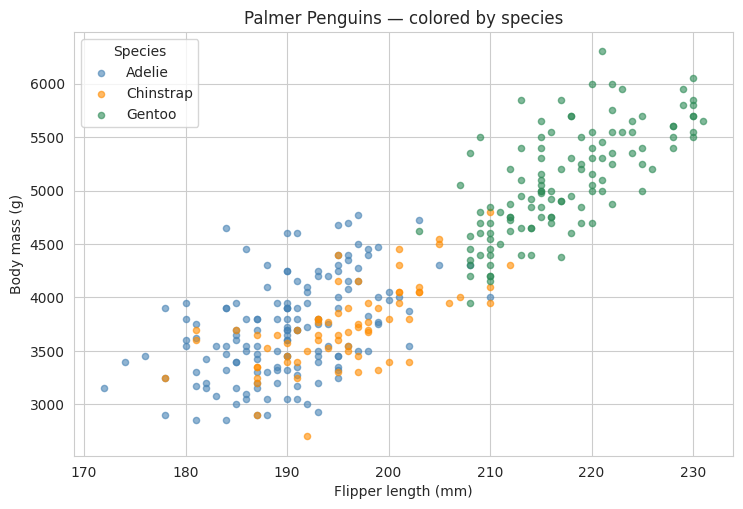

In [3]:
# Color the scatter by species to surface the cluster structure.
species_colors = {'Adelie': 'steelblue', 'Chinstrap': 'darkorange', 'Gentoo': 'seagreen'}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for species, grp in penguins.groupby('species'):
    ax.scatter(grp['flipper_length_mm'], grp['body_mass_g'],
               s=20, alpha=0.6, label=species, color=species_colors[species])
ax.set_xlabel('Flipper length (mm)')
ax.set_ylabel('Body mass (g)')
ax.set_title('Palmer Penguins — colored by species')
ax.legend(title='Species')
plt.show()

The clusters are the three species: Adelie (smallest), Chinstrap (medium), Gentoo (largest and longest-flipped). A single SLR line through all three is fitting an **average trend across a mixture of populations**. The overall slope (50 g/mm) is driven partly by the within-species relationship and partly by the fact that larger species happen to have longer flippers.

This is a preview of **omitted variable bias**: leaving out an important predictor (here, species) can distort the slope. We keep the single-line model for now to learn the mechanics cleanly, but the limitation is real and worth naming.

---

## Section 1: Paradigm A — Scikit-Learn (The Predictor)

Scikit-learn is the workhorse of predictive machine learning in Python. Its goal, ruthlessly, is: *given* $X$, *output* $\hat{y}$ *as fast and accurately as possible.* Every algorithm in scikit-learn (e.g, linear regression, random forests, neural networks, k-nearest neighbors) has the exact same three-method interface:

```python
model = SomeAlgorithm()
model.fit(X, y)       # learn from data
model.predict(X_new)  # make predictions
model.score(X, y)     # how well did we do?
```

That uniform API is why scikit-learn took over the world. Once you learn it for linear regression, you know it for every other model in the library.

But there is one famous beginner trap waiting for us before we can use it. Let's walk into it on purpose.

### The #1 beginner error in scikit-learn

The obvious first move is to hand scikit-learn our flipper-length column directly, the same way we'd hand it to NumPy or matplotlib. Let's try it and see what happens.

In [4]:
X_bad = penguins['flipper_length_mm']   # a 1D pandas Series — looks fine to us!
y_series = penguins['body_mass_g']

try:
    model = LinearRegression().fit(X_bad, y_series)
except Exception as err:
    print(f'{type(err).__name__}: {err}')

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


The error message is a little cryptic, but the fix is tiny and the reason is important:

> **Scikit-learn always expects `X` to be a 2D matrix, a table of features,  even when there's only one feature.**

Why? Because scikit-learn was designed for the general case of **multiple** linear regression (and every other multi-feature algorithm). The `X` matrix has one row per observation and one column per feature. When you hand it a 1D array, it can't tell whether you meant "one feature with $N$ observations" or "$N$ features with one observation." It refuses to guess.

The standard fix is `.reshape(-1, 1)`, which says *"reshape me into as many rows as necessary (`-1`) and exactly 1 column."*

In [5]:
# The fix: force X into a 2D column vector.
X = penguins['flipper_length_mm'].values.reshape(-1, 1)
y = penguins['body_mass_g'].values

print(f'Shape of X: {X.shape}   (rows, columns)')
print(f'Shape of y: {y.shape}   (1D is fine for y)')

Shape of X: (333, 1)   (rows, columns)
Shape of y: (333,)   (1D is fine for y)


Now `.fit()` works silently with no output and no fanfare. The model has quietly found the optimal slope and intercept (by solving the exact same $\text{argmin}(\text{RSS})$ problem we solved by hand in Notebook 17_0_5).

In [6]:
model_sk = LinearRegression()
model_sk.fit(X, y)

# Pull the learned parameters out of the fitted model.
slope_sk     = model_sk.coef_[0]        # coef_ is an array (one per feature)
intercept_sk = model_sk.intercept_
r2_sk        = model_sk.score(X, y)     # score() returns R^2 for regression

print(f'Scikit-learn slope (coef_):      {slope_sk:.4f} g/mm')
print(f'Scikit-learn intercept:          {intercept_sk:.4f} g')
print(f'Scikit-learn R^2 (.score):       {r2_sk:.4f}')

Scikit-learn slope (coef_):      50.1533 g/mm
Scikit-learn intercept:          -5872.0927 g
Scikit-learn R^2 (.score):       0.7621


Three numbers, and a real-world story:

- **Slope ≈ 50.2 g/mm.** For every extra millimeter of flipper, we expect the penguin to weigh about 50 grams more.
- **Intercept ≈ −5872 g.** Mathematically, a penguin with a flipper length of 0 mm would weigh −5.87 kg — nonsense, since no penguin has a zero-length flipper. The intercept is just the number that makes the line pass through the cloud of real penguins; it is *not* a scientific claim about hypothetical zero-flipper penguins.
- **$R^2 ≈ 0.76$.** Flipper length alone explains 76% of the variance in body mass. That's a *very* strong relationship for a single predictor in a biology dataset.

> **Rule: always ask whether $x = 0$ is meaningful before interpreting an intercept.** If $x = 0$ can't occur in your domain, the intercept has no scientific meaning — it's just a line-positioning constant. This is true of most intercepts in practice.

That's it. That's all scikit-learn will tell you. You asked for a predictor; it gave you a predictor.

---

## Section 2: Paradigm B — Statsmodels (The Explainer)

Now let's fit the exact same regression with **statsmodels** and see what a completely different philosophy looks like.

Where scikit-learn was built by ML engineers for prediction, statsmodels was built by statisticians for **inference** — using data to test whether a claimed relationship is statistically real, to put error bars on estimates, and to check whether the assumptions behind the model actually hold. Everything that scikit-learn hides to keep its API clean, statsmodels shows you on purpose.

We'll only skim the surface here. Most of what statsmodels gives us will be unpacked in the next few notebooks. For now, our job is just to (a) fit the model and (b) confirm we get the same slope.

### The statsmodels quirk: you must add the intercept yourself

Here is the second footgun of the notebook. Scikit-learn automatically fits an intercept unless you tell it not to. Statsmodels is the opposite:

> **By default, `sm.OLS` fits a line *forced through the origin* (intercept = 0). You must manually add a column of 1's to `X` to get the intercept back.**

The helper `sm.add_constant` does exactly that. It sticks a column of 1's onto the front of your feature matrix. The coefficient learned for that constant column *is* the intercept $b$.

In [7]:
# Start from the 1D flipper column (statsmodels is happy with 1D or 2D).
X_sm = sm.add_constant(penguins['flipper_length_mm'])

# Peek at what that actually did: a new 'const' column full of 1's.
X_sm.head()

,const,flipper_length_mm
0,1.0,181.0
1,1.0,186.0
2,1.0,195.0
3,1.0,193.0
4,1.0,190.0


Now we fit with `sm.OLS`. Note the argument order is `(y, X)` which is *different from scikit-learn's `(X, y)`*. 

The reason: sklearn's API centers on *predicting from inputs* — you give it features first, targets second: `fit(X, y)`. Statsmodels follows the statistical textbook convention, where the regression equation is written $y = X\beta + \epsilon$ — the thing you're explaining comes first: `OLS(y, X)`.

This catches everyone at least once.

In [8]:
# Argument order: y first, then X.
model_sm = sm.OLS(penguins['body_mass_g'], X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          3.13e-105
Time:                        10:34:16   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5872.0927    310.28

That is a *lot* of output compared to the three numbers scikit-learn gave us. Here is a quick orientation — not so you can interpret every row right now, but so you know what territory the table covers. Notebook 17_1_2 unpacks the inference columns in detail.

**Coefficient table (one row per predictor):**

| Column | What it is | Covered in |
|--------|-----------|------------|
| `coef` | The estimated slope (or intercept for `const`) | 17_1_1 (now) |
| `std err` | How much the slope would wiggle across different samples | 17_1_2 |
| `t` | The slope divided by its standard error — how many SEs the slope is from zero | 17_1_2 |
| `P>|t|` | Probability of seeing a slope this large by chance if the true slope were zero | 17_1_2 |
| `[0.025  0.975]` | A 95% confidence interval: a range of slopes consistent with the data | 17_1_2 |

**Top-right block:**
- `R-squared` / `Adj. R-squared`: fraction of variance in $y$ explained; we used this in 17_1_1
- `F-statistic` / `Prob (F-statistic)`: overall model significance test (equivalent to the t-test in SLR; more relevant in MLR)
- `AIC` / `BIC`: model comparison scores — lower is better; used when choosing between multiple models

**Bottom diagnostic rows** (Omnibus, Durbin-Watson, Jarque-Bera, Skew, Kurtosis): assumption checks covered in 17_1_3.

**The condition number footnote** (`2.9e+03`) warns about multicollinearity. In SLR this fires whenever the predictor and the constant column are on very different scales (flipper length is ~180–230; the constant is 1). It's a false alarm here — ignore it. It becomes meaningful when you have multiple predictors on mismatched scales.

For right now, let's pull the three numbers we do understand out programmatically.

In [9]:
intercept_sm = model_sm.params['const']
slope_sm     = model_sm.params['flipper_length_mm']
r2_sm        = model_sm.rsquared

print(f'Statsmodels slope:      {slope_sm:.4f} g/mm')
print(f'Statsmodels intercept:  {intercept_sm:.4f} g')
print(f'Statsmodels R^2:        {r2_sm:.4f}')

Statsmodels slope:      50.1533 g/mm
Statsmodels intercept:  -5872.0927 g
Statsmodels R^2:        0.7621


---

## Section 3: The Convergence

Here is the moment this notebook has been building toward. We have fit the same regression three different ways:

- Scikit-learn's `LinearRegression().fit()` (Section 1).
- Statsmodels' `sm.OLS(y, X_sm).fit()` (Section 2).
- The hand-derived closed-form formula $m = r \cdot \sigma_y / \sigma_x$, $b = \bar{y} - m\bar{x}$ from Notebook 17_0_5.

The first two produced pages of different-looking output. The third is five lines of NumPy. If everything we've claimed about what these libraries do under the hood is true, all three should produce the same slope, the same intercept, and the same $R^2$, to every digit of precision.

In [10]:
# The closed-form calculation from Notebook 17_0_5 — no libraries, just stats.
# RSS = residual sum of squares (how far predictions are from actual values).
# TSS = total sum of squares (how far actual values are from their mean).
# R^2 = 1 - RSS/TSS = fraction of variance explained.
x_flat = penguins['flipper_length_mm'].to_numpy()
y_flat = penguins['body_mass_g'].to_numpy()

x_mean  = np.mean(x_flat)
y_mean  = np.mean(y_flat)
# np.std defaults to ddof=0 (population std). Using ddof=1 (sample std) gives the
# same slope because sigma_y / sigma_x is a ratio — the n vs. n-1 factor cancels.
sigma_x = np.std(x_flat)
sigma_y = np.std(y_flat)
r_corr  = np.corrcoef(x_flat, y_flat)[0, 1]

slope_closed     = r_corr * (sigma_y / sigma_x)
intercept_closed = y_mean - slope_closed * x_mean

# R^2 from RSS and TSS, same as 17_0_5.
y_hat_closed = slope_closed * x_flat + intercept_closed
rss = np.sum((y_flat - y_hat_closed) ** 2)
tss = np.sum((y_flat - y_mean) ** 2)
r2_closed = 1 - rss / tss

print(f'Closed-form slope:      {slope_closed:.4f} g/mm')
print(f'Closed-form intercept:  {intercept_closed:.4f} g')
print(f'Closed-form R^2:        {r2_closed:.4f}')

Closed-form slope:      50.1533 g/mm
Closed-form intercept:  -5872.0927 g
Closed-form R^2:        0.7621


In [11]:
# Line all three methods up side by side.
comparison = pd.DataFrame({
    'Slope (m)':     [slope_sk,     slope_sm,     slope_closed],
    'Intercept (b)': [intercept_sk, intercept_sm, intercept_closed],
    'R^2':           [r2_sk,        r2_sm,        r2_closed],
}, index=['scikit-learn', 'statsmodels', 'closed-form (17_0_5)'])

comparison.round(6)

,Slope (m),Intercept (b),R^2
scikit-learn,50.153266,-5872.092683,0.762092
statsmodels,50.153266,-5872.092683,0.762092
closed-form (17_0_5),50.153266,-5872.092683,0.762092


**Identical to six decimal places.**

There is no magic in these libraries. Under the hood, `LinearRegression().fit()` and `sm.OLS().fit()` and a five-line NumPy calculation are all doing the same thing, finding the bottom of the RSS bowl we drew in Notebook 17_0_5. They differ in their *interface* and in *what they report back*, not in their math.

That's worth emphasizing because it is true of far more than linear regression. Almost every machine learning library you will ever use is, underneath the syntax, one of a handful of classical optimization problems that were worked out decades ago. The libraries are valuable because they're fast, well-tested, and general. Not because they know anything you don't.

### Residuals: What the Model Got Wrong

The fitted line is our best guess for every penguin's mass, but it won't be exact. Every penguin sits some distance above or below the line — those vertical gaps are the **residuals**:

$$e_i = y_i - \hat{y}_i$$

Plotting residuals is more informative than the scatter plot alone because it isolates the *pattern of errors*. If the errors look like random noise (no trend, roughly constant spread), the statistical machinery in the statsmodels table is on solid ground. If there's a curve, a funnel, or big clusters, something is off. We check this formally in 17_1_3 — here, just look.

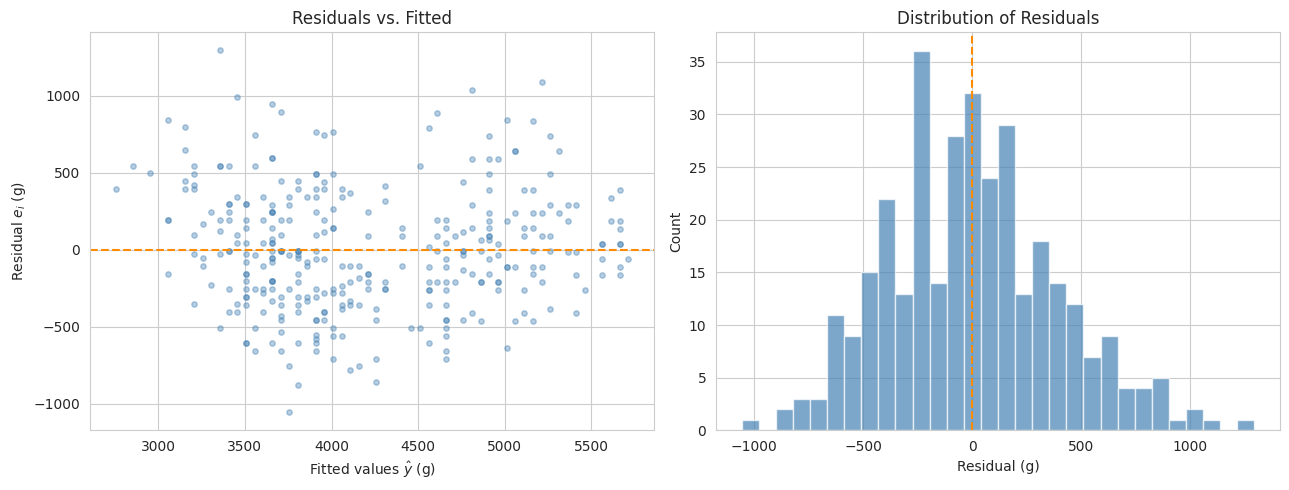

Mean residual:    -0.000000 g  (should be ~0 by construction)
Std of residuals: 392.16 g


In [12]:
# Compute residuals using the sklearn fit.
y_hat = model_sk.predict(X)
residuals = y_flat - y_hat

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: residuals vs. fitted values.
axes[0].scatter(y_hat, residuals, s=15, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='darkorange', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted values $\\hat{y}$ (g)')
axes[0].set_ylabel('Residual $e_i$ (g)')
axes[0].set_title('Residuals vs. Fitted')

# Right: histogram of residuals.
axes[1].hist(residuals, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='darkorange', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (g)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f'Mean residual:    {residuals.mean():.6f} g  (should be ~0 by construction)')
print(f'Std of residuals: {residuals.std():.2f} g')

Two things to notice:

1. **Residuals vs. Fitted (left)**: there is a slight fanning pattern — larger fitted values have slightly more spread. This is a hint that the equal-variance (homoscedasticity) assumption is only approximately satisfied. We'll test this formally in 17_1_3.
2. **Distribution of residuals (right)**: roughly bell-shaped and centered near zero — a good sign for the normality assumption.

The mean residual is zero (a mathematical guarantee of OLS: the line always passes through the centroid of the data). These two plots are the starting point for the full LINE assumption check in 17_1_3.

### Seeing the line

Let's end by looking at what all three methods actually *drew* on top of our penguins.

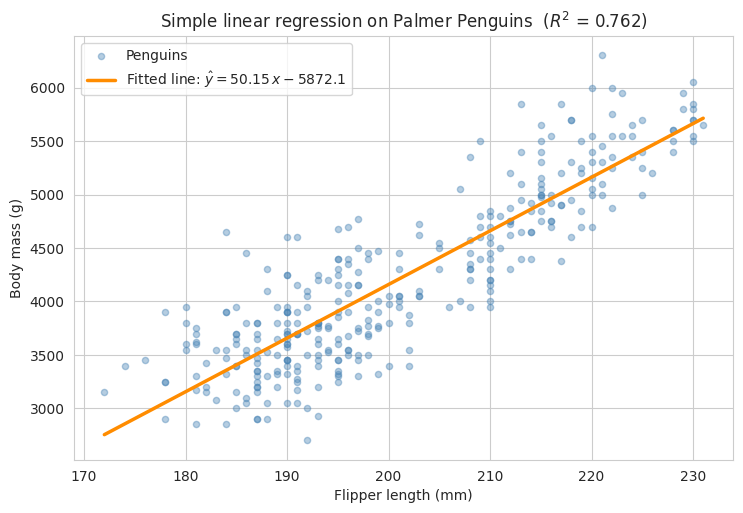

In [13]:
# Use scikit-learn's predict() to generate the line. (Any of the three would give
# the same line — we just picked one.)
x_grid = np.linspace(x_flat.min(), x_flat.max(), 100).reshape(-1, 1)
y_grid = model_sk.predict(x_grid)

sign = '-' if intercept_sk < 0 else '+'
label_str = fr'$\hat{{y}} = {slope_sk:.2f}\,x {sign} {abs(intercept_sk):.1f}$'

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x_flat, y_flat, s=20, alpha=0.4, color='steelblue', label='Penguins')
ax.plot(x_grid, y_grid, color='darkorange', linewidth=2.5,
        label=f'Fitted line: {label_str}')
ax.set_xlabel('Flipper length (mm)')
ax.set_ylabel('Body mass (g)')
ax.set_title(f'Simple linear regression on Palmer Penguins  ($R^2$ = {r2_sk:.3f})')
ax.legend()
plt.show()

---

## Putting It All Together

You now have three ways of fitting the same line, and you know they agree:

| Paradigm | Built for | Fit call | Key output |
|---|---|---|---|
| **scikit-learn** | Prediction | `LinearRegression().fit(X, y)` | `.coef_`, `.intercept_`, `.predict()`, `.score()` |
| **statsmodels**  | Inference  | `sm.OLS(y, sm.add_constant(X)).fit()` | `.params`, `.rsquared`, `.summary()`, p-values, CIs |
| **Closed form (17_0_5)** | Understanding the math | $m = r \sigma_y/\sigma_x$, $b = \bar{y} - m\bar{x}$ | $m$, $b$, $R^2$ |

And you've seen the two classic gotchas:

- **Scikit-learn:** `X` must be 2D. Use `.reshape(-1, 1)` for a single feature.
- **Statsmodels:** `X` must include a column of 1's if you want an intercept. Use `sm.add_constant`.

### How to choose between sklearn and statsmodels

- Use **sklearn** when your goal is **predictions**: you want `.predict()` on new data and don't need uncertainty around the slope.
- Use **statsmodels** when you need to **understand** the relationship: you want to report a standard error, test whether a predictor matters (p-value), or put a confidence interval on the slope.
- Many workflows use **both**: statsmodels for reporting and assumption-checking, sklearn for generating predictions on new data.

---

**YOUR TURN (10 min):** Load the Auto MPG dataset (`sns.load_dataset('mpg')`). Drop NaNs. Fit `mpg ~ displacement` using statsmodels. In a markdown cell below the fit, answer:

1. **Slope interpretation:** What does the slope mean in plain English? What does a one-unit increase in engine displacement predict for fuel economy, and in what direction?
2. **Intercept check:** Does the intercept make physical sense for this domain? Why or why not?
3. **Hidden structure:** Color your scatter plot by `cylinders`. Does the relationship between displacement and mpg look the same within each cylinder group as it does overall? What does that suggest about the single-line model?

---

### Where We're Going Next

Look again at that summary table from statsmodels. We now have a name for every column in it — but we've only truly *used* one: `coef`. Right next to it is `P>|t|` — arguably the most consequential number in applied statistics. It's what separates *"we found a slope in our sample"* from *"there is a real relationship in the world that our sample detected."*

That's the subject of `17_1_2_SLR_Significance.ipynb`. We'll ask: *did we actually find something, or did we just get lucky with 333 penguins?*